# American Sign Language (ASL) Detection
This notebook builds a CNN-based model to classify ASL alphabet images (29 classes).

In [ ]:
pip install tensorflow keras numpy matplotlib opencv-python

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Path to dataset files:", path)

100%|██████████| 1.03G/1.03G [00:12<00:00, 84.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1


In [ ]:
import os

# Paths
# Corrected train_dir to access the actual training image folders
train_dir = os.path.join(path, 'asl_alphabet_train', 'asl_alphabet_train')
# Keep test_dir pointing to the original sparse test set for potential future use (e.g., specific predictions)
test_dir = os.path.join(path, 'asl_alphabet_test')

IMG_SIZE = 32 # Reduced image size to significantly speed up training
BATCH_SIZE = 128 # Increased batch size to further speed up training
EPOCHS = 15


In [ ]:
print(f"Contents of original test directory ({test_dir}):")
try:
    test_files = os.listdir(test_dir)
    if test_files:
        print(f"  First 10 files: {test_files[:10]}...")
        print(f"  Total files found: {len(test_files)}")
    else:
        print("  Directory is empty.")
except FileNotFoundError:
    print(f"  Error: Directory not found at {test_dir}")
except Exception as e:
    print(f"  An error occurred: {e}")


Contents of original test directory (/root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1/asl_alphabet_test):
  First 10 files: ['asl_alphabet_test']...
  Total files found: 1


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2 # Allocate 20% of training data for validation
)

# We will use the same datagen to create both training and validation sets from 'train_dir'

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training' # Specify this is for the training subset
)

test_data = train_datagen.flow_from_directory( # Renamed 'validation_data' to 'test_data' for consistency with model.fit
    train_dir, # Use the same directory as training for the validation subset
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation', # Specify this is for the validation subset
    shuffle=False # Keep data in order for evaluation if needed
)

Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.


In [ ]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(29, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,653 (635.36 KB)

 Trainable params: 162,653 (635.36 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(29, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=EPOCHS
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,653 (635.36 KB)

 Trainable params: 162,653 (635.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 222s 398ms/step - accuracy: 0.2332 - loss: 2.5662 - val_accuracy: 0.3647 - val_loss: 2.0851
Epoch 2/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 214s 393ms/step - accuracy: 0.5346 - loss: 1.4385 - val_accuracy: 0.5039 - val_loss: 1.5860
Epoch 3/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 207s 380ms/step - accuracy: 0.6585 - loss: 1.0298 - val_accuracy: 0.5784 - val_loss: 1.3422
Epoch 4/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 262s 380ms/step - accuracy: 0.7247 - loss: 0.8101 - val_accuracy: 0.6179 - val_loss: 1.2108
Epoch 5/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 205s 376ms/step - accuracy: 0.7732 - loss: 0.6632 - val_accuracy: 0.6447 - val_loss: 1.1337
Epoch 6/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 204s 374ms/step - accuracy: 0.8064 - loss: 0.5660 - val_accuracy: 0.6682 - val_loss: 1.1510
Epoch 7/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 204s 375ms/step - accuracy: 0.8288 - loss: 0.4936 - val_accuracy: 0.6751 - val_loss: 1.0578
Epoch 8/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 205s 377ms/step - accuracy: 0.8452 -

In [ ]:
model.save('asl_model.h5')

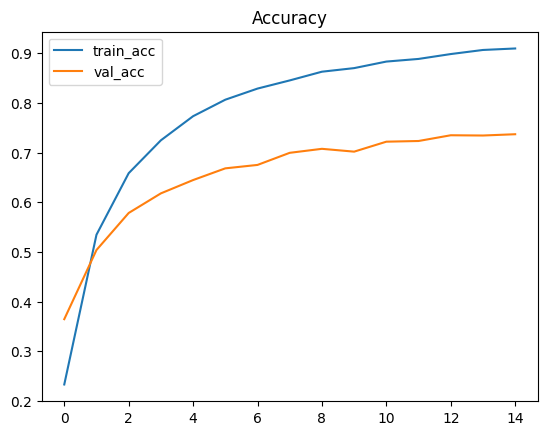

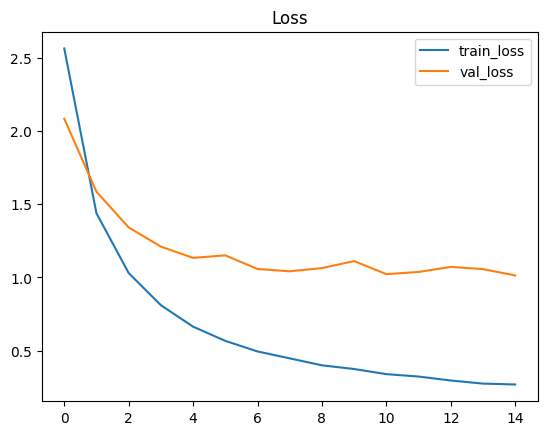

In [ ]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title('Accuracy')
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss')
plt.show()

In [ ]:
class_labels = list(train_data.class_indices.keys())

def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = np.reshape(img, (1, IMG_SIZE, IMG_SIZE, 3))

    prediction = model.predict(img)
    predicted_class = class_labels[np.argmax(prediction)]

    print('Predicted Sign:', predicted_class)

# Example
# predict_image('test_image.jpg')

## 9. Test Prediction

Let's test our trained model on a sample image from the test set to see its prediction.

In [ ]:
# The 'test_dir' from our setup was originally '/kaggle/input/asl-alphabet/asl_alphabet_test'.
# Inspecting its content previously showed a nested folder 'asl_alphabet_test'.
# Let's define the actual path to the test images.

# Adjust test_dir to point to the actual folder containing images if it's nested
# Based on previous output `os.listdir(test_dir)` = `['asl_alphabet_test']`,
# the structure seems to be `asl_alphabet_test/asl_alphabet_test/*.jpg`
actual_test_images_dir = os.path.join(test_dir, 'asl_alphabet_test')

# List files in this directory to pick a sample image
if os.path.exists(actual_test_images_dir) and os.listdir(actual_test_images_dir):
    sample_test_image = os.path.join(actual_test_images_dir, os.listdir(actual_test_images_dir)[0])
    print(f"Using sample test image: {sample_test_image}")
    predict_image(sample_test_image)
else:
    print(f"Could not find any images in {actual_test_images_dir} for prediction.")
    print("Please ensure the test directory contains images or upload a sample image to test.")


Using sample test image: /root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1/asl_alphabet_test/asl_alphabet_test/I_test.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Predicted Sign: del


## 10. Model Evaluation

Let's evaluate the model's performance on the validation dataset (which we've named `test_data` here) to get a comprehensive understanding of its accuracy and loss.

In [ ]:
loss, accuracy = model.evaluate(test_data)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

136/136 ━━━━━━━━━━━━━━━━━━━━ 31s 227ms/step - accuracy: 0.7371 - loss: 1.0174
Validation Loss: 1.0174
Validation Accuracy: 0.7371


### Classification Report and Confusion Matrix

To get a more detailed view of the model's performance, especially per-class metrics and common misclassifications, we'll generate a classification report and a confusion matrix.

## Strategies to Increase Model Accuracy



### 1. Enhanced Data Augmentation

While we already have some data augmentation, we can experiment with more aggressive or different augmentation techniques:

*   **More Rotation/Zoom/Shift:** Increase the ranges for `rotation_range`, `zoom_range`, and `width/height_shift_range`.
*   **Shear Transformation:** Add `shear_range` to introduce more variation.
*   **Brightness Changes:** Use `brightness_range` to simulate different lighting conditions.
*   **Feature-wise Normalization:** `featurewise_center` and `featurewise_std_normalization` can help if your dataset has consistent lighting/color biases.

In [ ]:
train_datagen_enhanced = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20, # Increased rotation
    zoom_range=0.2,    # Increased zoom
    width_shift_range=0.2, # Increased shift
    height_shift_range=0.2, # Increased shift
    shear_range=0.1,   # Added shear transformation
    brightness_range=[0.8, 1.2], # Added brightness variation
    horizontal_flip=True,
    validation_split=0.2
)


### 2. Deeper and Wider Model Architecture

Your current model is relatively shallow. You can add more convolutional layers or increase the number of filters:

*   **More Conv/Pooling Layers:** Add another block of `Conv2D` and `MaxPooling2D`.
*   **Increase Filters:** Start with more filters (e.g., 64, 128, 256) in the initial layers.
*   **Global Average Pooling:** Replace `Flatten` with `GlobalAveragePooling2D` to reduce parameters and prevent overfitting, especially for larger images.

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D

model_v2 = Sequential()

model_v2.add(Conv2D(64, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model_v2.add(MaxPooling2D(2,2))

model_v2.add(Conv2D(128, (3,3), activation='relu'))
model_v2.add(MaxPooling2D(2,2))

model_v2.add(Conv2D(256, (3,3), activation='relu'))
model_v2.add(MaxPooling2D(2,2))

# Using GlobalAveragePooling2D instead of Flatten
model_v2.add(GlobalAveragePooling2D())

model_v2.add(Dense(256, activation='relu')) # Increased dense layer units
model_v2.add(Dropout(0.5))

model_v2.add(Dense(29, activation='softmax'))

model_v2.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model_v2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 444,061 (1.69 MB)

 Trainable params: 444,061 (1.69 MB)

 Non-trainable params: 0 (0.00 B)

### 3. Transfer Learning

For image classification tasks, especially with limited datasets or for better generalization, using a pre-trained model on a large dataset like ImageNet can be highly effective. You can:

*   **Feature Extraction:** Use a pre-trained model (e.g., VGG16, ResNet, MobileNet) as a fixed feature extractor and add your own classification head on top.
*   **Fine-tuning:** Unfreeze some layers of the pre-trained model (typically the top convolutional blocks) and retrain them along with your new classification head with a very low learning rate.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Ensure IMG_SIZE is defined for this cell's self-containment
IMG_SIZE = 32

# Load pre-trained MobileNetV2 without the top classification layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=Input(shape=(IMG_SIZE, IMG_SIZE, 3)))

# Freeze the base model layers
base_model.trainable = False

# Create a new model on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(29, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=predictions)

transfer_model.compile(optimizer=Adam(learning_rate=0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

transfer_model.summary()

/tmp/ipykernel_803/4190530655.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=Input(shape=(IMG_SIZE, IMG_SIZE, 3)))


Model: "functional_44"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 16, 16,    │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 16, 16,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 16, 16,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 16, 16,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 16, 16,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 16, 16,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 17, 17,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 8, 8, 96)  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │          0 │ block_1_depthwis… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 8, 8, 24)  │      2,304 │ block_1_depthwis

 Total params: 2,593,373 (9.89 MB)

 Trainable params: 335,389 (1.28 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Training the MobileNetV2 Model (Feature Extraction)

In [ ]:
print('Training MobileNetV2 model...')
history_transfer = transfer_model.fit(
    train_data,
    validation_data=test_data,
    epochs=EPOCHS,
    # Add callbacks for early stopping and learning rate reduction if desired
    # callbacks=[early_stopping, reduce_lr]
)
print('MobileNetV2 model training complete.')

Training MobileNetV2 model...
Epoch 1/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 205s 355ms/step - accuracy: 0.1816 - loss: 2.8759 - val_accuracy: 0.1695 - val_loss: 2.9092
Epoch 2/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 187s 343ms/step - accuracy: 0.2318 - loss: 2.6418 - val_accuracy: 0.1758 - val_loss: 2.8686
Epoch 3/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 183s 336ms/step - accuracy: 0.2489 - loss: 2.5745 - val_accuracy: 0.1924 - val_loss: 2.8241
Epoch 4/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 185s 341ms/step - accuracy: 0.2586 - loss: 2.5300 - val_accuracy: 0.1970 - val_loss: 2.8098
Epoch 5/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 187s 343ms/step - accuracy: 0.2681 - loss: 2.4988 - val_accuracy: 0.1955 - val_loss: 2.7952
Epoch 6/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 182s 334ms/step - accuracy: 0.2755 - loss: 2.4732 - val_accuracy: 0.2021 - val_loss: 2.7697
Epoch 7/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 182s 334ms/step - accuracy: 0.2814 - loss: 2.4536 - val_accuracy: 0.2051 - val_loss: 2.7590
Epoch 8/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 185s 3

### Plotting Training History for MobileNetV2

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_transfer.history['accuracy'], label='train_acc')
plt.plot(history_transfer.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title('MobileNetV2 Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history_transfer.history['loss'], label='train_loss')
plt.plot(history_transfer.history['val_loss'], label='val_loss')
plt.legend()
plt.title('MobileNetV2 Loss')

plt.show()

### Saving the Trained MobileNetV2 Model

In [ ]:
transfer_model.save('asl_mobilenetv2_model.h5')
print('MobileNetV2 model saved as asl_mobilenetv2_model.h5')

### Improved Evaluation Metrics for MobileNetV2

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluate the transfer model
loss_transfer, accuracy_transfer = transfer_model.evaluate(test_data)
print(f"MobileNetV2 Validation Loss: {loss_transfer:.4f}")
print(f"MobileNetV2 Validation Accuracy: {accuracy_transfer:.4f}")

# Get true labels (already available from previous execution: y_true)
# Get predicted probabilities for transfer model
y_pred_prob_transfer = transfer_model.predict(test_data)

# Get predicted labels for transfer model
y_pred_transfer = np.argmax(y_pred_prob_transfer, axis=1)

# Generate classification report
print("\nMobileNetV2 Classification Report:")
print(classification_report(y_true, y_pred_transfer, target_names=class_labels))

# Generate confusion matrix
conf_matrix_transfer = confusion_matrix(y_true, y_pred_transfer)

plt.figure(figsize=(15, 12))
sns.heatmap(conf_matrix_transfer, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('MobileNetV2 Confusion Matrix')
plt.show()

### Grad-CAM Visualizations for MobileNetV2

Grad-CAM (Gradient-weighted Class Activation Mapping) helps visualize which parts of an input image are most important for the model's prediction. We'll implement a function to generate Grad-CAM heatmaps for specific predictions.

In [ ]:
import tensorflow as tf

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that maps the input image to the activations of the last convolutional layer
    # and the final output predictions.
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last convolutional layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen) with respect to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the feature map array by "how important this channel is" with regard to the top predicted class
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    # Load the original image
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize heatmap to original image size and convert to BGR for overlay
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Superimpose the heatmap on the original image
    superimposed_img = heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.title(f"Grad-CAM for predicted class: {class_labels[transfer_model.predict(np.expand_dims(img/255.0, axis=0)).argmax()]}")
    plt.show()

# Find the name of the last convolutional layer in MobileNetV2
# This can vary based on the specific architecture, typically it's the last layer before the global pooling
# Let's inspect the model summary to find a suitable layer
last_conv_layer_name = None
for layer in reversed(transfer_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

if last_conv_layer_name:
    print(f"Last convolutional layer found: {last_conv_layer_name}")
else:
    print("Could not find a convolutional layer in the model for Grad-CAM.")

# Example usage for Grad-CAM:
# Pick a sample image from the test set
if os.path.exists(actual_test_images_dir) and os.listdir(actual_test_images_dir):
    sample_gradcam_image_path = os.path.join(actual_test_images_dir, os.listdir(actual_test_images_dir)[0])

    # Preprocess the image for the model
    img = cv2.imread(sample_gradcam_image_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_array = np.expand_dims(img / 255.0, axis=0)

    # Generate heatmap
    heatmap = make_gradcam_heatmap(img_array, transfer_model, last_conv_layer_name)

    # Display Grad-CAM
    display_gradcam(sample_gradcam_image_path, heatmap)
else:
    print("Could not find any images for Grad-CAM visualization.")

### 4. Hyperparameter Tuning

Experiment with different hyperparameters:

*   **Learning Rate:** Try different learning rates for the Adam optimizer (e.g., 0.01, 0.0005, 0.0001).
*   **Batch Size:** You increased it to 128, but try smaller (e.g., 64) or larger (e.g., 256) to see its impact.
*   **Epochs:** Train for more epochs if the validation accuracy is still improving, but watch out for overfitting. Use Early Stopping.
*   **Dropout Rate:** Experiment with the `Dropout` rate (e.g., 0.3, 0.6).

### 5. Regularization

*   **L1/L2 Regularization:** Add `kernel_regularizer` to convolutional and dense layers to penalize large weights and prevent overfitting.
*   **Batch Normalization:** Add `BatchNormalization` layers after convolutional layers and before activation functions to stabilize training and speed it up.

In [ ]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.regularizers import l2

model_regularized = Sequential()

model_regularized.add(Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3), kernel_regularizer=l2(0.001)))
model_regularized.add(BatchNormalization())
model_regularized.add(MaxPooling2D(2,2))

model_regularized.add(Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.001)))
model_regularized.add(BatchNormalization())
model_regularized.add(MaxPooling2D(2,2))

model_regularized.add(Conv2D(128, (3,3), activation='relu', kernel_regularizer=l2(0.001)))
model_regularized.add(BatchNormalization())
model_regularized.add(MaxPooling2D(2,2))

model_regularized.add(Flatten())

model_regularized.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
model_regularized.add(Dropout(0.5))

model_regularized.add(Dense(29, activation='softmax'))

model_regularized.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model_regularized.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,549 (638.86 KB)

 Trainable params: 163,101 (637.11 KB)

 Non-trainable params: 448 (1.75 KB)

### 6. Early Stopping and Learning Rate Scheduling

These callbacks can prevent overfitting and optimize training:

*   **Early Stopping:** Stop training when validation loss stops improving for a certain number of epochs (`patience`).
*   **ReduceLROnPlateau:** Reduce the learning rate when validation loss plateaus.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

# We would pass these callbacks to model.fit:
# history = model.fit(
#     train_data,
#     validation_data=test_data,
#     epochs=EPOCHS,
#     callbacks=[early_stopping, reduce_lr]
# )

By systematically trying these approaches, we should be able to significantly improve the accuracy of your ASL detection model.

136/136 ━━━━━━━━━━━━━━━━━━━━ 30s 219ms/step
Classification Report:
              precision    recall  f1-score   support

           A       0.89      0.72      0.80       600
           B       0.72      0.92      0.81       600
           C       0.93      0.95      0.94       600
           D       0.97      0.80      0.88       600
           E       0.60      0.88      0.71       600
           F       0.89      0.94      0.91       600
           G       0.86      0.83      0.85       600
           H       0.80      0.90      0.85       600
           I       0.95      0.46      0.62       600
           J       0.89      0.71      0.79       600
           K       0.99      0.84      0.91       600
           L       0.97      0.96      0.97       600
           M       0.51      0.54      0.52       600
           N       0.35      0.43      0.39       600
           O       0.70      0.69      0.69       600
           P       0.73      0.84      0.78       600
           Q  

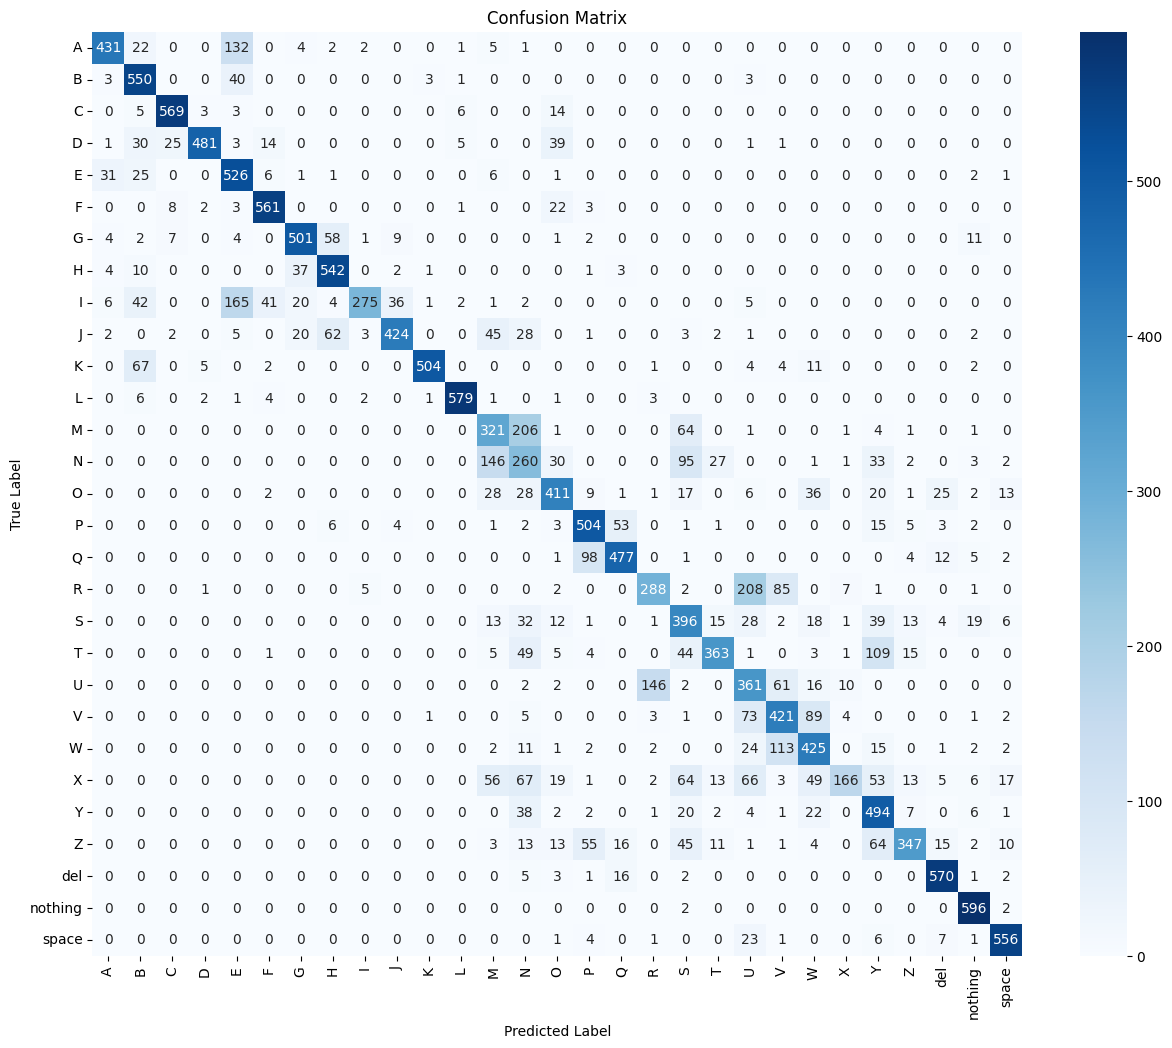

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns # Import seaborn for heatmap visualization

# Get true labels
y_true = test_data.classes

# Get predicted probabilities
y_pred_prob = model.predict(test_data)

# Get predicted labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Generate classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(15, 12))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()